In [1]:
# Code block 0.1

# Import some non-landlab libraries
import numpy as np
import matplotlib as mpl

# Import from the landlab library
from landlab import RasterModelGrid, imshow_grid, imshowhs_grid
from landlab.components import FastscapeEroder, FlowAccumulator, LinearDiffuser, ChannelProfiler
from landlab.plot.graph import plot_graph
from tqdm import trange

In [2]:
import numpy as np
from landlab import RasterModelGrid
import matplotlib.pyplot as plt
from landlab.components import (
    FlowAccumulator,
    DepressionFinderAndRouter,
    Space,
    FastscapeEroder,
)

### Instantiate a grid

In [3]:
num_rows = 150  # number of grid rows
num_cols = 200  # number of grid columns
dxy = 10  # resolution of raster cell [m], or node horizontal and vertical spacing

# Create the grid
mg = RasterModelGrid((num_rows, num_cols), dxy)

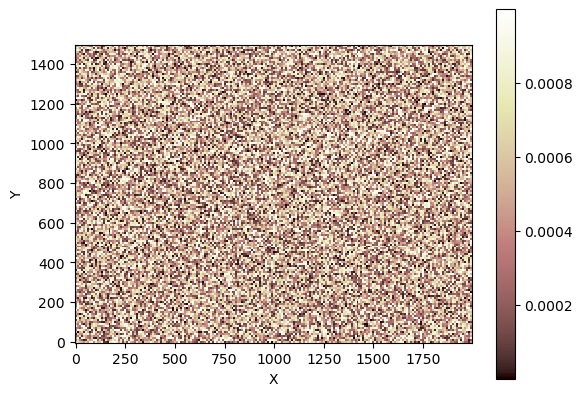

In [4]:
# Make some noise to add to the initial topography.
# This is not necessary, but it is a trick to make networks look more `real`

np.random.seed(0)  
mg_noise = np.random.rand(mg.number_of_nodes) / 1000.0  # intial noise on elevation grid

# Set-up the elevation field on the grid
zr = mg.add_zeros("topographic__elevation", at="node")
zr += mg_noise

# Plot the elevation map
imshow_grid(mg, "topographic__elevation")

### Set parameters and create an instance of the flow accumulation and fluvial erosion components

In [5]:
# Stream power parameters
K_sp = 1.0e-5  # erodibility, units depend on m and n exponents
m_sp = 0.5  # exponent on drainage area
n_sp = 1.0  # exponent on slope

# Create the flow accumulation and fluvial incision components
fr = FlowAccumulator(mg, flow_director="D8")
fs = FastscapeEroder(mg, m_sp=m_sp, n_sp=n_sp, K_sp=K_sp)

### Set model time and uplift parameters

In [6]:
dt = 1000  # time step [yr]
modeled_time = 0  # amount of time the landscape has evolved [yr]
time_to_run = 3e6  # time for the model loop to run [yr]

nsteps = int(time_to_run / dt)  # number of model time steps

uplift_rate = 0.0001  # uplift rate [m/yr]
uplift_length = uplift_rate * dt # length of uplift per time step [m]

In [7]:
# close every edge
mg.set_closed_boundaries_at_grid_edges(True, True, True, True)
outlet_node = 0
# reopen just that node as a fixed-value outlet
mg.status_at_node[outlet_node] = mg.BC_NODE_IS_FIXED_VALUE

### Run the fluvial model

In [8]:
for i in range(nsteps):
    zr[mg.core_nodes] += uplift_length  # uplift the landscape
    fr.run_one_step()  # route flow
    fs.run_one_step(dt)  # fluvial incision
    modeled_time += dt  # update time keeper
    
    # sometimes it's nice to see that the model is progressing, especially if it's slow
    if int(modeled_time % 1e5) == 0:
        print("model run time",modeled_time)
        print("maximum elevation",max(mg.at_node["topographic__elevation"][mg.core_nodes]))
        

model run time 100000
maximum elevation 10.000693887971533
model run time 200000
maximum elevation 20.000451005436364
model run time 300000
maximum elevation 30.000278291335178
model run time 400000
maximum elevation 40.00019491564104
model run time 500000
maximum elevation 50.00013180283757
model run time 600000
maximum elevation 60.00008971551122
model run time 700000
maximum elevation 70.00006420701115
model run time 800000
maximum elevation 80.0000522178176
model run time 900000
maximum elevation 90.00003751271377
model run time 1000000
maximum elevation 100.00002468209748
model run time 1100000
maximum elevation 110.0000174624747
model run time 1200000
maximum elevation 120.00001245227273
model run time 1300000
maximum elevation 130.00000875944897
model run time 1400000
maximum elevation 140.00000687870573
model run time 1500000
maximum elevation 150.00000514805544
model run time 1600000
maximum elevation 160.00000057556184
model run time 1700000
maximum elevation 169.977485338520

### Visualize the topography

In [15]:
# imshow_grid(mg, "topographic__elevation")
max(mg.at_node["topographic__elevation"])

np.float64(110.83034257322177)

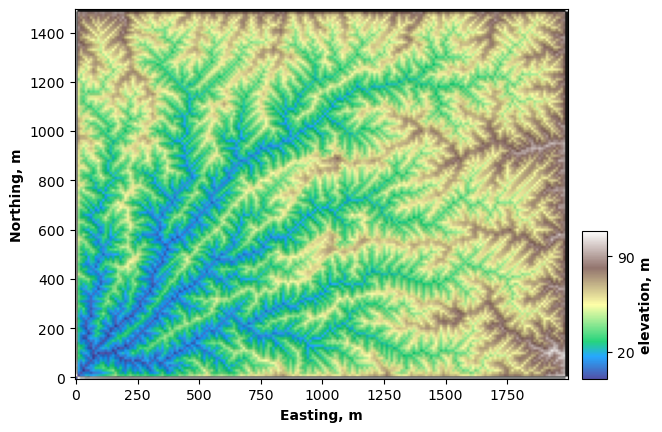

In [10]:
# Elevation map draped over shaded relief
# Don't get thrown off by all the parameter values.
# They are included because this function makes beautiful visualizations,
# and it can be helpful to `see` different aspects of the landscape by changing
# the parameters.

cmap = mpl.colormaps["terrain"]
plot_type = "Drape1"
#plot_type = "DEM"
drape1 = "topographic__elevation"
ax = imshowhs_grid(
    mg,
    "topographic__elevation",
    plot_type=plot_type,
    drape1=drape1,
    alpha=0.85,
#    altdeg=55.,
#    azdeg=180,
    cmap=cmap,
    grid_units=("m", "m"),
    default_fontsize=10,
    cbar_tick_size=10,
    var_name="elevation, m",
    cbar_width="100%",
    cbar_or="vertical",
    bbox_to_anchor=[1.03, 0.0, 0.05, 8],
    colorbar_label_y=3,
    #colorbar_label_x=-100,
    ticks_km=False,
)

### A drainage area map

Because drainage area varies by orders of magnitude, it is often easier to visualize on a log scale. Plotting drainage area is one way to visualize the networks. It is also helpful to see if the model has developed continuous networks.

Text(0.5, 1.0, 'log10 of drainage area, time = 3000000')

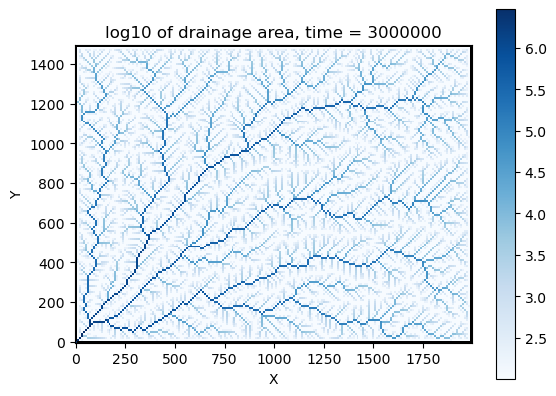

In [11]:
# calculate the log of drainage area array
log10area = np.log10(mg.at_node["drainage_area"] + 1.0)

# make the map
imshow_grid(mg, log10area, cmap="Blues")
title_text = f"log10 of drainage area, time = {modeled_time}"
mpl.pyplot.title(title_text)

## Space Tryout Tutorial

In [179]:
import numpy as np
from landlab import RasterModelGrid
from landlab.components import (
    FlowAccumulator,
    DepressionFinderAndRouter,
    Space,
    FastscapeEroder,
)

In [145]:
# mg = RasterModelGrid((5, 5), xy_spacing=10.0)
# _ = mg.add_zeros("topographic__elevation", at="node")
# mg.at_node["topographic__elevation"] += (
#     mg.node_y / 10.0 + mg.node_x / 10.0 + np.random.rand(len(mg.node_y)) / 10.0)
# mg.set_closed_boundaries_at_grid_edges(bottom_is_closed=True,left_is_closed=True,right_is_closed=True,
# top_is_closed=True)
# mg.set_watershed_boundary_condition_outlet_id(
#     0, mg.at_node["topographic__elevation"], -9999.0)
# fsc_dt = 100.0
# space_dt = 100.0

In [146]:
# fr = FlowAccumulator(mg, flow_director="D8")
# df = DepressionFinderAndRouter(mg)
# fsc = FastscapeEroder(mg, K_sp=0.001, m_sp=0.5, n_sp=1)

In [147]:
# for _ in range(100):
#     fr.run_one_step()
#     df.map_depressions()
#     fsc.run_one_step(dt=fsc_dt)
#     mg.at_node["topographic__elevation"][0] -= 0.001  # Uplift

In [148]:
# imshow_grid(mg, "topographic__elevation")

#### Adding Soil to the Drainage Network

In [149]:
_ = mg.add_zeros("soil__depth", at="node", dtype=float)
mg.at_node["soil__depth"] += 2.0
mg.at_node["topographic__elevation"] += mg.at_node["soil__depth"]

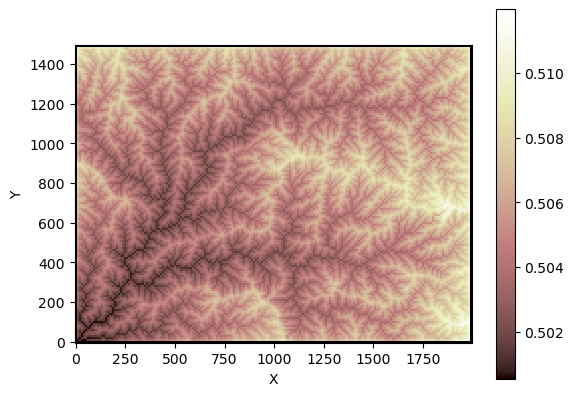

In [150]:
imshow_grid(mg, "topographic__elevation")

#### Space without Rainfall

In [151]:
ha = Space(
    mg,
    K_sed=0.001,
    K_br=0.000001,
    F_f=0.5,
    phi=0.1,
    H_star=1.0,
    v_s=0.001,
    m_sp=0.5,
    n_sp=1.0,
    sp_crit_sed=0,
    sp_crit_br=0,
)

In [159]:
### This one takes 10 mins to run

fsc_dt = 100.0
space_dt = 1.0
df = DepressionFinderAndRouter(mg) 
for _ in range(366):  # Space component loop
    fr.run_one_step()
    df.map_depressions()
    ha.run_one_step(dt=space_dt)
    # mg.at_node["bedrock__elevation"][0] -= 2e-6 * space_dt
    print(f"model run completed for dt {_}")

model run completed for dt 0


KeyboardInterrupt: 

In [153]:
np.around(mg.at_node["soil__depth"], decimals=3)

array([0.5, 0.5, 0.5, ..., 0.5, 0.5, 0.5], shape=(30000,))

In [154]:
np.around(mg.at_node["topographic__elevation"], decimals=3)

array([0.501, 0.501, 0.501, ..., 0.501, 0.501, 0.501], shape=(30000,))

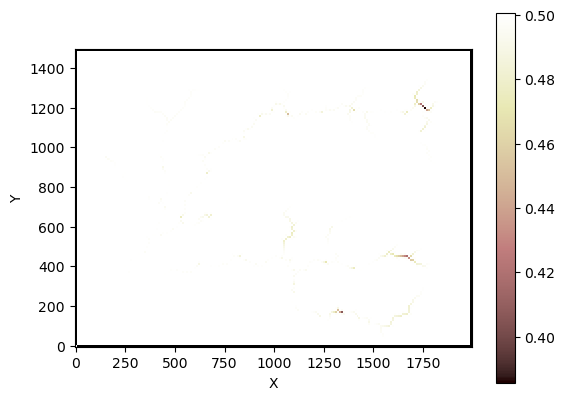

In [158]:
# imshow_grid(mg, "topographic__elevation")
imshow_grid(mg, "topographic__elevation")

In [156]:
mg.at_node.keys()

['topographic__elevation',
 'water__unit_flux_in',
 'drainage_area',
 'flow__data_structure_delta',
 'flow__upstream_node_order',
 'surface_water__discharge',
 'flow__sink_flag',
 'flow__link_to_receiver_node',
 'flow__receiver_node',
 'topographic__steepest_slope',
 'soil__depth',
 'sediment__influx',
 'sediment__outflux',
 'sediment__flux',
 'bedrock__elevation',
 'depression__depth',
 'depression__outlet_node',
 'is_pit',
 'flood_status_code']

## Space with Single Rainfall as Runoff

In [17]:
_ = mg.add_zeros("soil__depth", at="node", dtype=float)
mg.at_node["soil__depth"] += 2.0
mg.at_node["topographic__elevation"] += mg.at_node["soil__depth"]

FieldError: Unable to add the field, 'soil__depth', to the group, 'node', because a field with that name already exists in that group. Use `clobber=True` to replace the existing field. For example, grid.add_field('soil__depth', at='node', clobber=True)

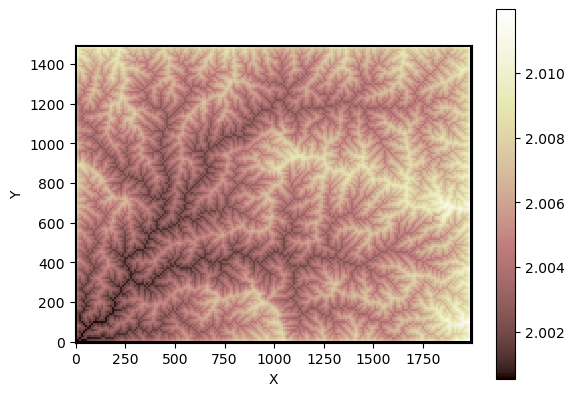

In [18]:
imshow_grid(mg, "topographic__elevation")

#### Space

In [19]:
ha = Space(
    mg,
    K_sed=0.0001,
    K_br=0.000000001,
    F_f=0.5,
    phi=0.1,
    H_star=1.0,
    v_s=0.001,
    m_sp=0.5,
    n_sp=1.0,
    sp_crit_sed=0,
    sp_crit_br=0,
)

In [20]:
### This one takes 10 mins to run

fr = FlowAccumulator(mg, flow_director="D8", runoff_rate = 23.0)
df = DepressionFinderAndRouter(mg)

fsc_dt = 100.0
space_dt = 1.0
df = DepressionFinderAndRouter(mg) 
for _ in range(36):  # Space component loop
    fr.run_one_step()
    df.map_depressions()
    ha.run_one_step(dt=space_dt)
    # mg.at_node["bedrock__elevation"][0] -= 2e-6 * space_dt
    print(f"model run completed for dt {_}")

FlowAccumulator found both the field 'water__unit_flux_in' and a provided float or array for the runoff_rate argument. THE FIELD IS BEING OVERWRITTEN WITH THE SUPPLIED RUNOFF_RATE!
model run completed for dt 0
model run completed for dt 1
model run completed for dt 2
model run completed for dt 3
model run completed for dt 4
model run completed for dt 5
model run completed for dt 6
model run completed for dt 7
model run completed for dt 8
model run completed for dt 9
model run completed for dt 10
model run completed for dt 11
model run completed for dt 12
model run completed for dt 13
model run completed for dt 14
model run completed for dt 15
model run completed for dt 16
model run completed for dt 17
model run completed for dt 18
model run completed for dt 19
model run completed for dt 20
model run completed for dt 21
model run completed for dt 22
model run completed for dt 23
model run completed for dt 24
model run completed for dt 25
model run completed for dt 26
model run completed

In [21]:
np.around(mg.at_node["soil__depth"], decimals=3)

array([2., 2., 2., ..., 2., 2., 2.], shape=(30000,))

In [22]:
np.around(mg.at_node["topographic__elevation"], decimals=3)

array([2.001, 2.001, 2.001, ..., 2.001, 2.001, 2.001], shape=(30000,))

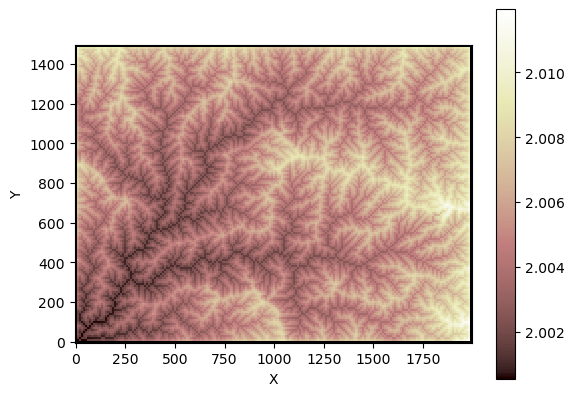

In [23]:
# imshow_grid(mg, "topographic__elevation")
imshow_grid(mg, "topographic__elevation")

## Space with Variable Rainfall as Runoff

In [37]:
_ = mg.add_zeros("soil__depth", at="node", dtype=float)
mg.at_node["soil__depth"] += 2.0
mg.at_node["topographic__elevation"] += mg.at_node["soil__depth"]

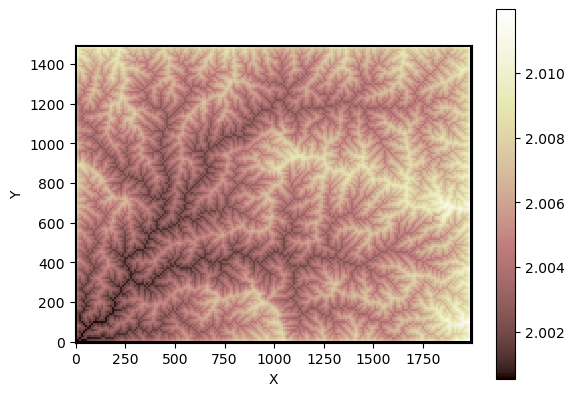

In [38]:
imshow_grid(mg, "topographic__elevation")

#### Space

In [49]:
ha = Space(
    mg,
    K_sed=0.0001,
    K_br=0.000000001,
    F_f=0.5,
    phi=0.1,
    H_star=1.0,
    v_s=0.001,
    m_sp=0.5,
    n_sp=1.0,
    sp_crit_sed=0,
    sp_crit_br=0,
)

In [79]:
runoff_array = np.random.rand(36)
len(runoff_array)
np.random.uniform(0, 5, 36).mean()
np.clip(np.random.normal(2, 0.5, 36), 0, None).mean()

np.float64(2.0586816040759803)

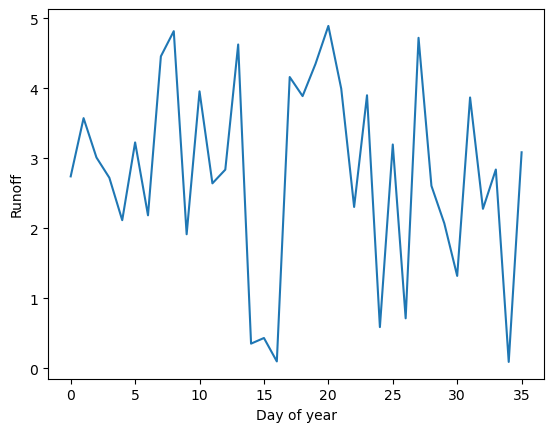

In [81]:
## Runoff timeseries
# runoff_array = np.narry(365 values)
# plot runoff_array

np.random.seed(0)
runoff_array = np.random.uniform(0, 5, 36)



import matplotlib.pyplot as plt
plt.plot(runoff_array)
plt.xlabel("Day of year")
plt.ylabel("Runoff")
plt.show()

In [82]:
### This one takes 10 mins to run

# fr = FlowAccumulator(mg, flow_director="D8", runoff_rate = 23.0)
df = DepressionFinderAndRouter(mg)

fsc_dt = 100.0
space_dt = 1.0
df = DepressionFinderAndRouter(mg) 
for _ in range(36):  # Space component loop
    fr = FlowAccumulator(mg, flow_director="D8", runoff_rate = runoff_array[_])
    fr.run_one_step()
    df.map_depressions()
    ha.run_one_step(dt=space_dt)
    # mg.at_node["bedrock__elevation"][0] -= 2e-6 * space_dt
    print(f"model run completed for dt {_}")

FlowAccumulator found both the field 'water__unit_flux_in' and a provided float or array for the runoff_rate argument. THE FIELD IS BEING OVERWRITTEN WITH THE SUPPLIED RUNOFF_RATE!
model run completed for dt 0
FlowAccumulator found both the field 'water__unit_flux_in' and a provided float or array for the runoff_rate argument. THE FIELD IS BEING OVERWRITTEN WITH THE SUPPLIED RUNOFF_RATE!
model run completed for dt 1
FlowAccumulator found both the field 'water__unit_flux_in' and a provided float or array for the runoff_rate argument. THE FIELD IS BEING OVERWRITTEN WITH THE SUPPLIED RUNOFF_RATE!
model run completed for dt 2
FlowAccumulator found both the field 'water__unit_flux_in' and a provided float or array for the runoff_rate argument. THE FIELD IS BEING OVERWRITTEN WITH THE SUPPLIED RUNOFF_RATE!
model run completed for dt 3
FlowAccumulator found both the field 'water__unit_flux_in' and a provided float or array for the runoff_rate argument. THE FIELD IS BEING OVERWRITTEN WITH THE S

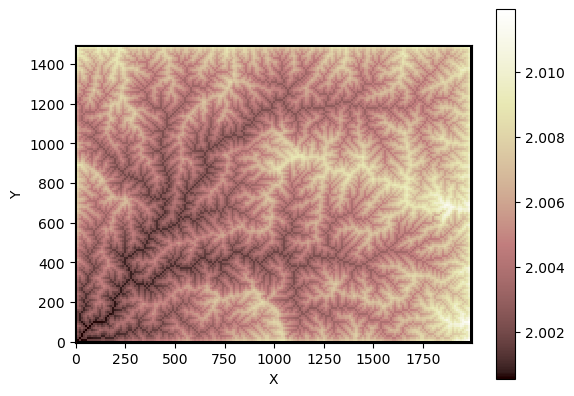

In [85]:
# imshow_grid(mg, "topographic__elevation")
imshow_grid(mg, "topographic__elevation")

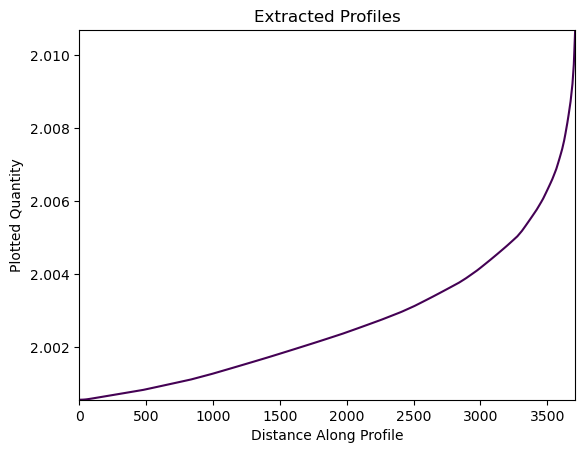

In [87]:
# Instantiate the ChannelProfiler component.
# The drainage area map can be helpful for deciding the minimum channel threshold.
prf = ChannelProfiler(mg, number_of_watersheds=1, minimum_channel_threshold=1e2)

# Run the component and plot the profiles
prf.run_one_step()
prf.plot_profiles()

In [126]:
# Plot the channels on map
# prf.plot_profiles_in_map_view()
# prf.nodes

In [89]:
mg.at_node.keys()

['topographic__elevation',
 'drainage_area',
 'flow__data_structure_delta',
 'flow__upstream_node_order',
 'surface_water__discharge',
 'flow__link_to_receiver_node',
 'flow__receiver_node',
 'topographic__steepest_slope',
 'soil__depth',
 'sediment__influx',
 'sediment__outflux',
 'sediment__flux',
 'bedrock__elevation',
 'depression__depth',
 'depression__outlet_node',
 'is_pit',
 'flood_status_code',
 'water__unit_flux_in',
 'flow__sink_flag']

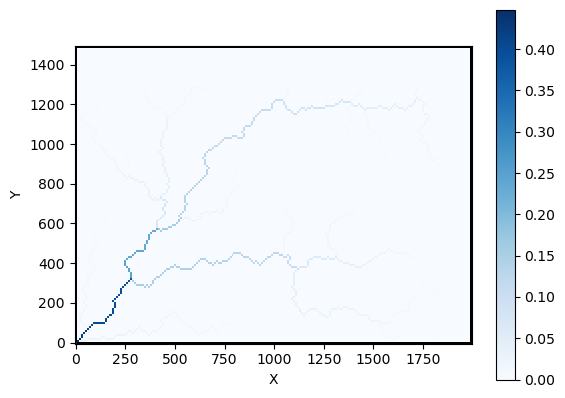

In [104]:
# imshow_grid(mg, "topographic__elevation")
imshow_grid(mg, "sediment__influx", cmap="Blues")

## Field Extraction at Specific Node

In [20]:
mg.at_node["topographic__elevation"][0],
mg.at_node["sediment__influx"][0],
mg.at_node["sediment__outflux"][0], 
mg.at_node["bedrock__elevation"][0],
mg.at_node["surface_water__discharge"][0]

topoelevation.append(np.round((mg.at_node["topographic__elevation"][0]), decimals=5))

#### Space Run

In [16]:
_ = mg.add_zeros("soil__depth", at="node", dtype=float)
mg.at_node["soil__depth"] += 2.0
mg.at_node["topographic__elevation"] += mg.at_node["soil__depth"]


FieldError: Unable to add the field, 'soil__depth', to the group, 'node', because a field with that name already exists in that group. Use `clobber=True` to replace the existing field. For example, grid.add_field('soil__depth', at='node', clobber=True)

In [17]:
elevation_T1 = mg.at_node["topographic__elevation"]
elevation_T1

array([2.00054881, 2.00071519, 2.00060276, ..., 2.0008529 , 2.00073423,
       2.000639  ], shape=(30000,))

In [19]:
ha = Space(
    mg,
    K_sed=0.01,
    K_br=0.001,
    F_f=1,
    phi=0.1,
    H_star=1.0,
    v_s=1,
    m_sp=0.5,
    n_sp=1.0,
    sp_crit_sed=0,
    sp_crit_br=0,
)

In [20]:
runoff_array = np.random.rand(30)
len(runoff_array)

30

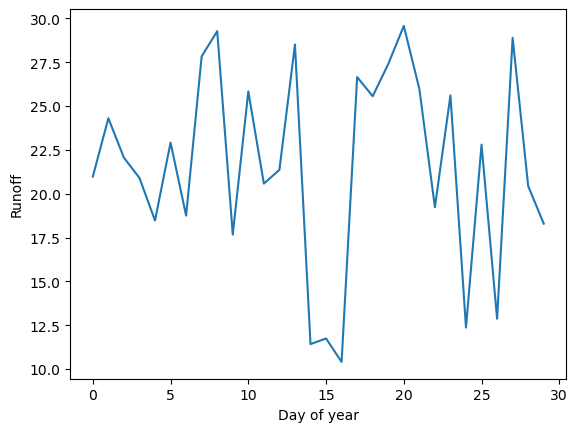

In [21]:
np.random.seed(0)
runoff_array = np.random.uniform(10, 30, 30)

plt.plot(runoff_array)
plt.xlabel("Day of year")
plt.ylabel("Runoff")
plt.show()

In [17]:
topoelevation = []
sed_in = []
sed_out = []
sed_flux = []
discharge = []
bedrock_elvtn = []

# mg.at_node["topographic__elevation"][0],
# mg.at_node["sediment__influx"][0],
# mg.at_node["sediment__outflux"][0], 
# mg.at_node["bedrock__elevation"][0],
# mg.at_node["surface_water__discharge"][0]

In [18]:
### This one takes 10 mins to run

space_dt = 10.0
df = DepressionFinderAndRouter(mg) 
for _ in trange(50):  # Space component loop
    fr = FlowAccumulator(mg, flow_director="D8", runoff_rate = runoff_array[_])
    fr.run_one_step()
    df.map_depressions()
    ha.run_one_step(dt=space_dt)
    topoelevation.append(np.round((mg.at_node["topographic__elevation"][0]), decimals=5))
    sed_in.append(np.round((mg.at_node["sediment__influx"][0]), decimals=5))
    sed_out.append(np.round((mg.at_node["sediment__outflux"][0]), decimals=5))
    sed_flux.append(np.round((mg.at_node["sediment__flux"][0]), decimals=5))
    discharge.append(np.round((mg.at_node["surface_water__discharge"][0]), decimals=5))
    bedrock_elvtn.append(np.round((mg.at_node["bedrock__elevation"][0]), decimals=5))
    # print(f"model run completed for dt {_}")

  0%|          | 0/50 [00:00<?, ?it/s]

FlowAccumulator found both the field 'water__unit_flux_in' and a provided float or array for the runoff_rate argument. THE FIELD IS BEING OVERWRITTEN WITH THE SUPPLIED RUNOFF_RATE!


  2%|▏         | 1/50 [00:02<02:26,  2.98s/it]

FlowAccumulator found both the field 'water__unit_flux_in' and a provided float or array for the runoff_rate argument. THE FIELD IS BEING OVERWRITTEN WITH THE SUPPLIED RUNOFF_RATE!


  4%|▍         | 2/50 [00:05<02:21,  2.95s/it]

...

 96%|█████████▌| 48/50 [21:15<01:04, 32.37s/it]

FlowAccumulator found both the field 'water__unit_flux_in' and a provided float or array for the runoff_rate argument. THE FIELD IS BEING OVERWRITTEN WITH THE SUPPLIED RUNOFF_RATE!


 98%|█████████▊| 49/50 [21:47<00:32, 32.29s/it]

FlowAccumulator found both the field 'water__unit_flux_in' and a provided float or array for the runoff_rate argument. THE FIELD IS BEING OVERWRITTEN WITH THE SUPPLIED RUNOFF_RATE!


100%|██████████| 50/50 [22:19<00:00, 26.79s/it]


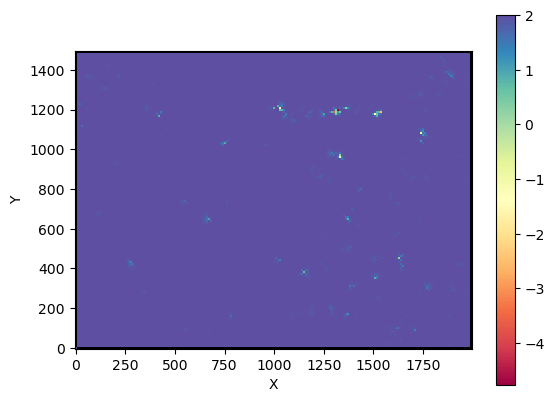

In [19]:
imshow_grid(mg, "topographic__elevation", cmap="Spectral")

In [21]:
elevation_TX = mg.at_node["topographic__elevation"]
topoelvtn_diff = elevation_TX - elevation_T1
topoelvtn_diff

array([0., 0., 0., ..., 0., 0., 0.], shape=(30000,))

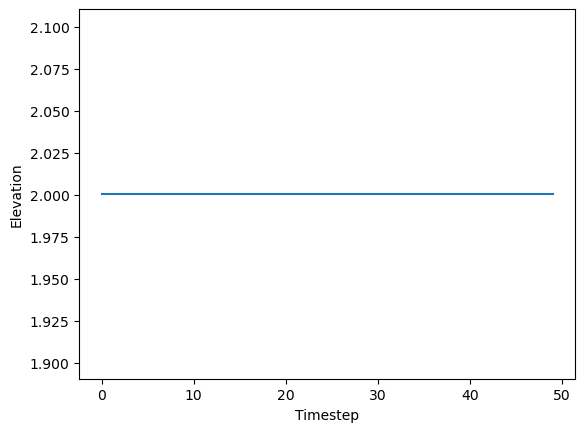

In [19]:
timesteps = np.arange(0, 50)

plt.plot(timesteps, topoelevation)
plt.xlabel("Timestep")
plt.ylabel("Elevation")
plt.show()

## Viz Ideas

- Rivers Water Level with Soil Level
- 1961 to 2014 ------ Resulted more than 20m Sediment Accumulation [Resulted in capactiy loss of the dam]
- 